# Вычислительная ниткография

Алгоритм по портретной фотографии строт схему расположения нитей.
Метод основан на **Filtered Back Projection** из рентгеновской томографии.

In [81]:
import numpy as np
from pathlib import Path

from fbp_solution.string_art import (
    load_grayscale_square,
    prepare_fbp_image,
    bilinear_sample,
    circle_mask,
    draw_threads,
)
from fbp_solution.utils import show_image, show_side_by_side, show_sinogram, show_binary_mask, show_threads_on_black

## Исходное изображение

Загружаем, проверяем квадратную и одноканальную картинку.

Размер: 437×437, диапазон: [0.02, 1.00]


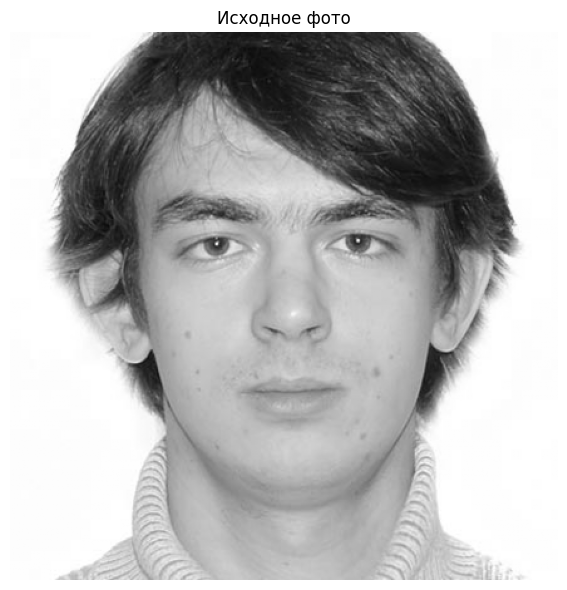

In [82]:
input_path = Path("input.png")
image = load_grayscale_square(input_path)
print(f'Размер: {image.shape[0]}×{image.shape[1]}, диапазон: [{image.min():.2f}, {image.max():.2f}]')

show_image(image, 'Исходное фото')

## Подготовка

Поднятием общей яркости исходного изображения устраняем отрицательные значения.
Инвертируем, чтобы тёмные детали (глаза, волосы) получили больше нитей.

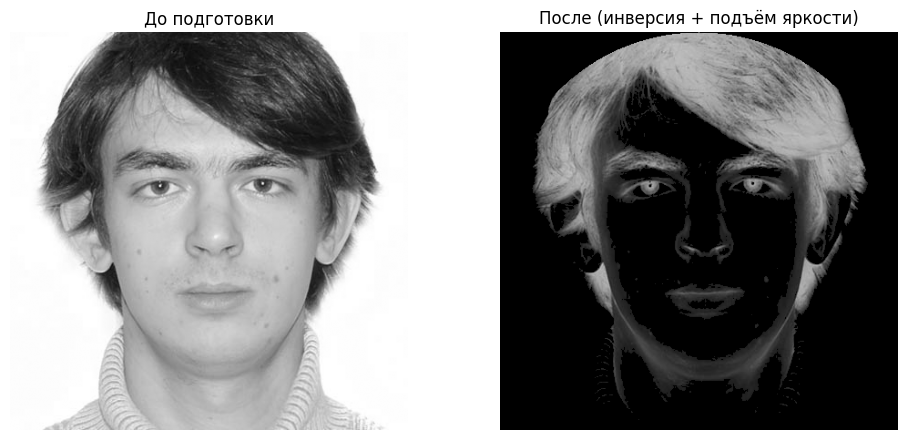

In [83]:
target = prepare_fbp_image(image, brightness_lift=0.2)

show_side_by_side(image, target, 'До подготовки', 'После (инверсия + подъём яркости)')

## Шаг 1. Преобразование Радона

> *«$R[f(x,y)](\rho,\varphi) = \int_{-\infty}^{\infty} f(\rho\cos\varphi - l\sin\varphi,\; \rho\sin\varphi + l\cos\varphi)\,dl$»*

Для каждого угла $\varphi$ проводим набор параллельных прямых и суммируем яркость вдоль каждой.
Результат — **синограмма**: строки = углы, столбцы = смещения $\rho$.

In [84]:
def radon_transform(image, angle_count):
    size = image.shape[0]
    center = (size - 1) / 2
    image = image * circle_mask(size)

    offsets = np.arange(size) - center
    line_points = np.linspace(-center, center, size)
    angles = np.linspace(0.0, 180.0, angle_count, endpoint=False)
    sinogram = np.zeros((angle_count, size), dtype=float)

    for angle_index, angle in enumerate(angles):
        phi = np.deg2rad(angle)
        cos_phi = np.cos(phi)
        sin_phi = np.sin(phi)

        x = offsets[:, None] * cos_phi - line_points[None, :] * sin_phi
        y = offsets[:, None] * sin_phi + line_points[None, :] * cos_phi

        rows = center + y
        cols = center + x
        sinogram[angle_index] = bilinear_sample(image, rows, cols).sum(axis=1)

    return sinogram, angles

Синограмма: 360 углов × 437 смещений


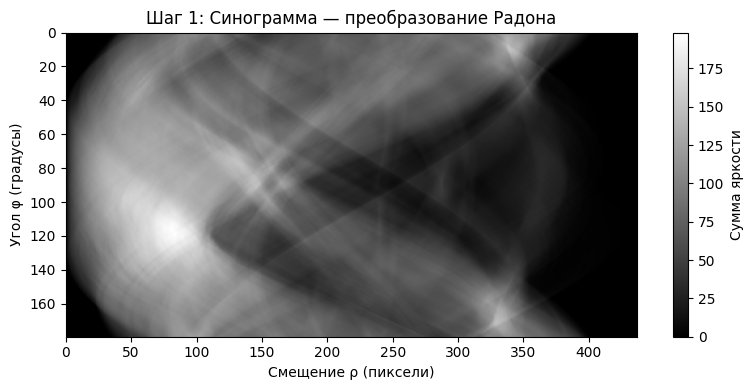

In [85]:
ANGLES = 360

sinogram, angles = radon_transform(target, ANGLES)
print(f'Синограмма: {sinogram.shape[0]} углов × {sinogram.shape[1]} смещений')

show_sinogram(sinogram, angles, 'Шаг 1: Синограмма — преобразование Радона',
              colorbar_label='Сумма яркости')

## Шаг 2. Свертка с рамп-фильтром

> *«$F_r(\rho)$ при $\rho=0$: $1/4$; при чётном $\rho$: $0$; при нечётном: $-1/(\pi\rho)^2$»*

Каждую проекцию сворачиваем с этим фильтром — подчёркиваем границы и детали.
После фильтрации могут появиться отрицательные значения.

In [86]:
def ramp_kernel(size):
    offsets = np.arange(-(size // 2), size - size // 2)
    kernel = np.zeros(size, dtype=float)

    kernel[offsets == 0] = 1 / 4
    odd = (offsets % 2 != 0)
    kernel[odd] = -1 / (np.pi * offsets[odd]) ** 2

    return kernel


def filter_sinogram(sinogram):
    kernel = ramp_kernel(sinogram.shape[1])
    filtered = np.zeros_like(sinogram)

    for angle_index, projection in enumerate(sinogram):
        filtered[angle_index] = np.convolve(projection, kernel, mode="same")

    return filtered

Минимум после фильтрации: -4.24 (отрицательные — нормально)


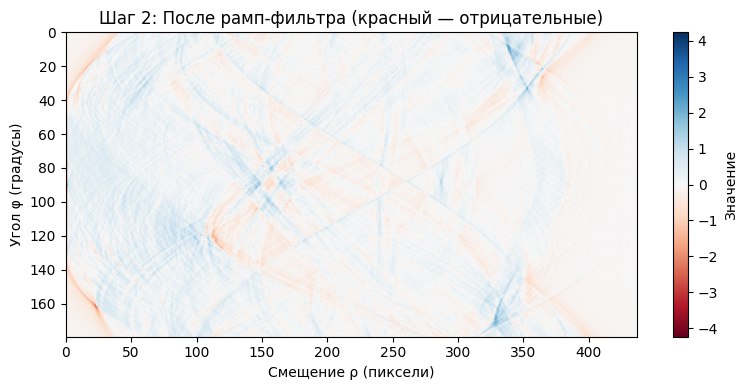

In [87]:
filtered = filter_sinogram(sinogram)
print(f'Минимум после фильтрации: {filtered.min():.2f} (отрицательные — нормально)')

show_sinogram(filtered, angles, 'Шаг 2: После рамп-фильтра (красный — отрицательные)',
              cmap='RdBu', colorbar_label='Значение',
              vmin=-np.abs(filtered).max(), vmax=np.abs(filtered).max())

## Шаг 3. Прореживание

Прореживание проекций по пространственной переменной до заданного числа нитей.

Из всех возможных прямых под каждым углом оставляем только **40 самых ярких**.
Остальные зануляем — нитей будет регулируемое количество.

In [88]:
def keep_brightest_per_angle(sinogram, thread_count):
    kept = np.zeros_like(sinogram)
    thread_count = min(thread_count, sinogram.shape[1])

    for angle_index, projection in enumerate(sinogram):
        indices = np.argpartition(projection, -thread_count)[-thread_count:]
        kept[angle_index, indices] = projection[indices]

    return kept

Оставлено 85718 из 157320 ячеек (54.5%)


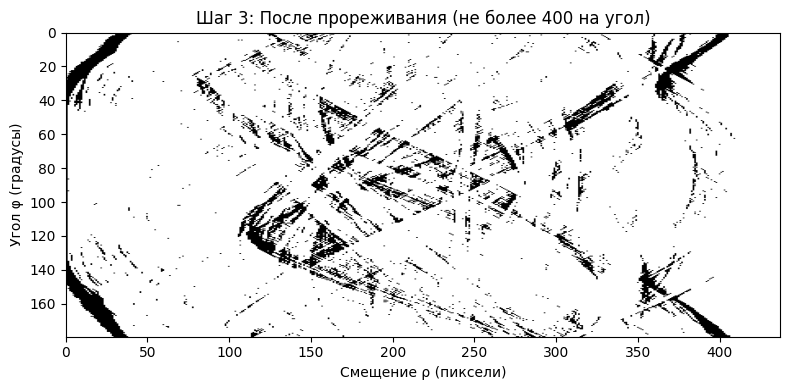

In [89]:
THREADS = 400

thinned = keep_brightest_per_angle(filtered, THREADS)
nonzero = (thinned > 0).sum()
total = thinned.size
print(f'Оставлено {nonzero} из {total} ячеек ({100*nonzero/total:.1f}%)')

show_binary_mask(thinned != 0, angles, f'Шаг 3: После прореживания (не более {THREADS} на угол)')

## Шаг 4. Нормировка

Занулим точки синограммы, значения которых меньше 0; нормируем оставшийся диапазон к отрезку $[0,1]$

Отрицательные → 0, остальные приводим к вероятностям от 0 до 1.
Теперь каждое число = вероятность того, что нить будет протянута.

In [90]:
def normalize_sinogram_probabilities(sinogram, gamma=0.85):
    normalized = sinogram.copy()
    normalized[normalized < 0] = 0

    for angle_index, projection in enumerate(normalized):
        row = projection.copy()
        row[row < 0] = 0.0
        maximum = row.max()

        if maximum <= 0:
            continue

        row = (row / maximum) ** gamma
        normalized[angle_index] = row

    return normalized

Диапазон вероятностей: [0.000, 1.000]


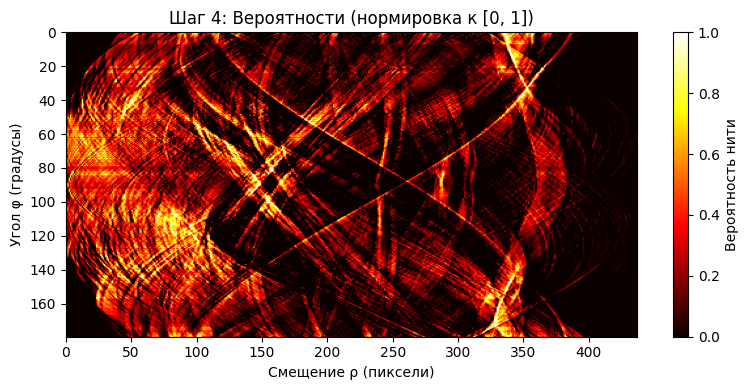

In [91]:
probabilities = normalize_sinogram_probabilities(thinned, gamma=0.85)
print(f'Диапазон вероятностей: [{probabilities.min():.3f}, {probabilities.max():.3f}]')

show_sinogram(probabilities, angles, 'Шаг 4: Вероятности (нормировка к [0, 1])',
              cmap='hot', colorbar_label='Вероятность нити', vmin=0, vmax=1)

## Шаг 5. Бинарное распыление

В каждом пикселе выходной синограммы поставим 1 с вероятностью, указанной в этом пикселе, иначе поставим 0

In [92]:
def binary_dither(probabilities, seed):
    random = np.random.default_rng(seed).random(probabilities.shape)
    return (random < probabilities).astype(np.uint8)

Нитей: 22549


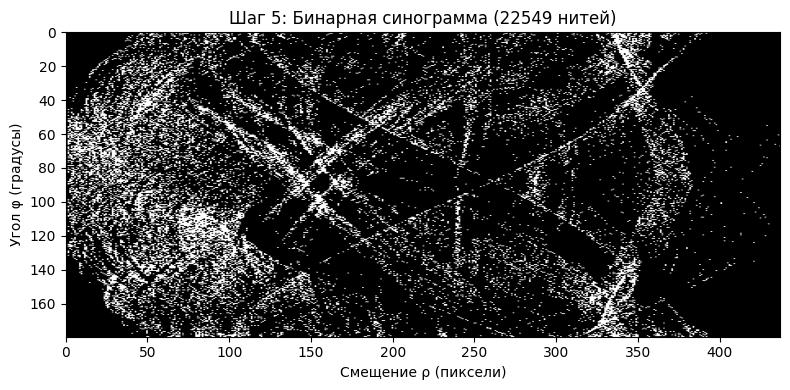

In [93]:
binary = binary_dither(probabilities, seed=1)
thread_count = binary.sum()
print(f'Нитей: {thread_count}')

show_binary_mask(binary, angles, f'Шаг 5: Бинарная синограмма ({thread_count} нитей)')

## Результат — обратная проекция

Построим обратную проекцию данной бинарной синограммы

Каждая единица в бинарной синограмме = одна нить. Протягиваем все нити и смотрим, что получилось.
Для контраста применяем *«контрастирование с зашкаливанием небольшого числа пикселей с высокой яркостью»*.

In [94]:
def binary_sinogram_to_lines(binary_sinogram, angles, probabilities=None):
    center = (binary_sinogram.shape[1] - 1) / 2
    lines = []
    weights = []

    for angle_index, offset_index in np.argwhere(binary_sinogram > 0):
        angle = float(angles[angle_index])
        offset = float(offset_index - center)
        lines.append((angle, offset))
        if probabilities is not None:
            weights.append(float(probabilities[angle_index, offset_index]))
        else:
            weights.append(1.0)

    return lines, weights

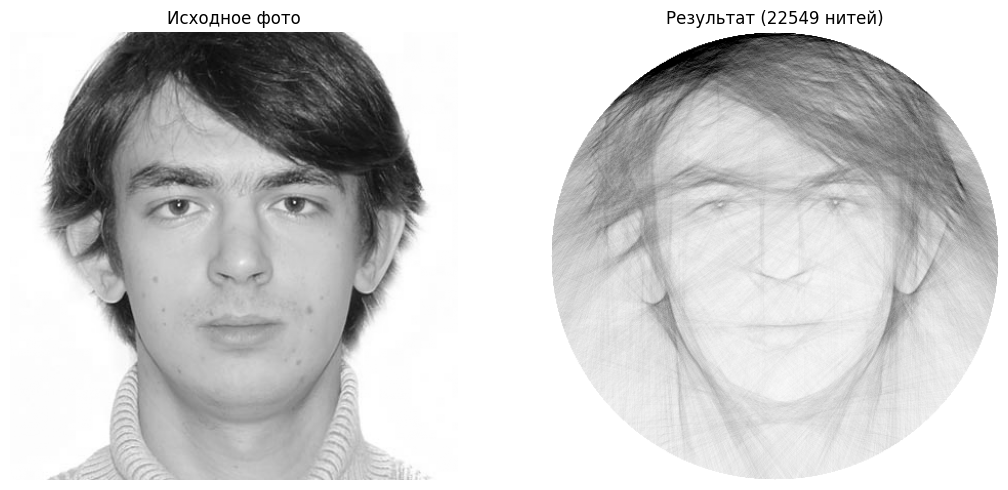

In [95]:
lines, weights = binary_sinogram_to_lines(binary, angles, probabilities)
size = image.shape[0]

canvas = draw_threads(lines, size, weights=weights)

# Контрастирование (quantile 0.995 — «зашкаливание» по заданию)
positive = canvas[canvas > 0]
limit = np.quantile(positive, 0.995) if positive.size > 0 else 1.0
preview = np.clip(canvas, 0, limit)
preview /= preview.max()

# Инверсия для отображения: нити -> тёмные (как на фото)
display = 1.0 - preview

show_side_by_side(image, display, 'Исходное фото', f'Результат ({thread_count} нитей)',
                    figsize=(11, 5))

## Белые нити на чёрном фоне


Ниже — как выглядит реальная картина из ниток (без инверсии, нити белые).

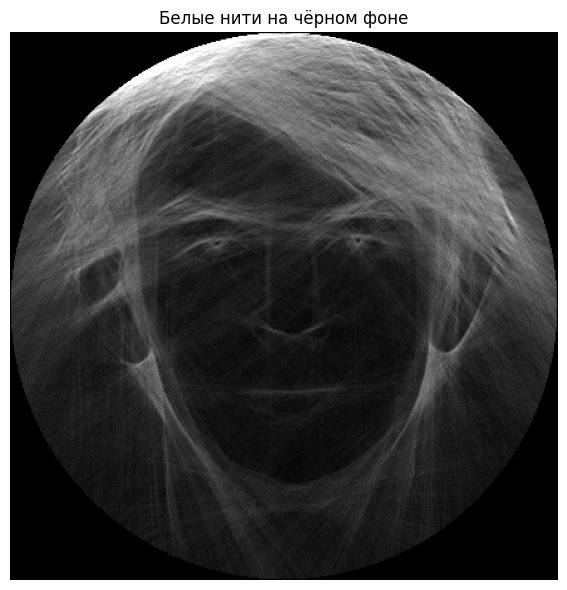

In [96]:
show_threads_on_black(preview, 'Белые нити на чёрном фоне')

## Возможные улучшения

Текущий результат (RMSE ≈ 0.84) далёк от идеала. Основная причина — FBP не оптимизирует расположение нитей целенаправленно, он лишь фильтрует синограмму. Вот что можно улучшить в рамках текущего подхода и за его пределами.

### В рамках FBP

**1. Замена random dither на error-diffusion.**
Случайный дизеринг — источник шума. Error-diffusion распространяет ошибку на соседние ячейки синограммы, и общее количество нитей точнее соответствует исходным вероятностям. Уже реализовано (`--dither-mode error-diffusion`).

**2. Больше углов, умнее прореживание.**
360 углов × 40 нитей = 8418 нитей, но выбор по `argpartition` — грубый. Можно:
- увеличить число углов до 720+;
- вместо «40 самых ярких» использовать порог по значению: брать все нити выше определённого уровня — это сохранит важные детали и отбросит шум.

**3. Адаптивная гамма-коррекция.**
Сейчас `--prob-gamma 0.85` одинаков для всех углов. Но на углах, где контраст высокий (лицо), нужна одна гамма, а где контраст низкий (фон) — другая. Адаптивная гамма по каждому углу улучшит детализацию.

**4. Взвешивание по важности (importance map).**
В портрете глаза и рот важнее лба. Можно создать карту важности и умножить на неё вероятности sinogram — нити будут точнее в ключевых зонах. Этот приём используют [Birsak et al.](https://www.dmg.tuwien.ac.at/geom/ig/publications/stringart/stringart.pdf) и [Bridges 2022](https://hal.science/hal-03901755/file/bridges2022-63.pdf).

### За рамками FBP (кардинальные улучшения)

**5. Жадный алгоритм по остатку (greedy).**
Стандарт де-факто для ниткографии — greedy: на каждом шаге выбирается хорда, которая максимально уменьшает ошибку между текущим холстом и целевым изображением. Реализации: [grvlbit/stringart](https://github.com/grvlbit/stringart), [DanAla/String_Art](https://github.com/DanAla/String_Art). RMSE падает с 0.84 до ~0.02–0.19.

**6. Полупрозрачные нити.**
Вместо бинарных (есть/нет) можно протягивать нити с переменной прозрачностью. Это даёт более тонкие переходы, особенно в глазах и рту ([Bridges 2022](https://hal.science/hal-03901755/file/bridges2022-63.pdf)).

**7. Гвозди на окружности + хорды вместо (angle, ρ).**
FBP работает с параллельными прямыми, но в реальной ниткографии нити натягиваются между гвоздями на рамке. Переход к хордам между гвоздями даёт более реалистичную схему и лучшие результаты — именно так работают все современные реализации.